# Исследование пользовательской активности в сервисе чтения

**Цель:** проверить гипотезу о том, что пользователи из Санкт-Петербурга в среднем проводят больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы.

**Задачи:**

* загрузить подготовленные данные о времени активности пользователей Москвы и Санкт-Петербурга;
* проверить наличие дубликатов и сравнить размеры исследуемых групп;
* изучить основные статистические показатели и распределение времени активности пользователей;
* выбрать подходящий статистический тест и определить уровень статистической значимости;
* провести односторонний t-тест для сравнения среднего времени активности пользователей двух городов;
* рассчитать и интерпретировать p-value;
* на основе результатов статистического теста принять или отвергнуть нулевую гипотезу;
* определить возможные причины полученного результата и подготовить аналитическую записку.

## Описание данных

Для исследования используются данные об активности пользователей сервиса чтения из Москвы и Санкт-Петербурга. Данные содержат информацию о суммарном времени, которое пользователи провели за чтением и прослушиванием контента в течение исследуемого периода.

## Содержимое проекта
* Загрузка данных и знакомство с ними
* Исследование данных
* Проверка гипотезы
* Аналитические выводы

# Загрузка данных и знакомство с ними

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st

In [2]:
yandex_knigi = pd.read_csv('https://code.s3.yandex.net//datasets/yandex_knigi_data.csv')
yandex_knigi.head()

,Unnamed: 0,city,puid,hours
0,0,Москва,9668,26.167776
1,1,Москва,16598,82.111217
2,2,Москва,80401,4.656906
3,3,Москва,140205,1.840556
4,4,Москва,248755,151.326434


In [3]:
# Удоляем дублирующую колонку индекса датафрейма
yandex_knigi = yandex_knigi.drop(columns='Unnamed: 0')
yandex_knigi.head()

,city,puid,hours
0,Москва,9668,26.167776
1,Москва,16598,82.111217
2,Москва,80401,4.656906
3,Москва,140205,1.840556
4,Москва,248755,151.326434


# Исследование данных

In [4]:
# Разделяем на группы Москва и СПБ
moscow = yandex_knigi.loc[yandex_knigi['city']=='Москва']
spb = yandex_knigi.loc[yandex_knigi['city']=='Санкт-Петербург']
print(f'Москва')
print(moscow.head())
print('---'*22)
print(f'СПБ')
print(spb.head())
print('---'*22)

# Проверяем дубликаты
groups = {'Москва': moscow,
          'Санкт-Петербург': spb}

for city, df in groups.items():
    duplicates = df['puid'].duplicated().sum()
    print(f'Количество дубликатов пользователей в группе {city}: {duplicates}')
    
# Распределение по группам
print('---' * 22)
print('Распределение по группам')
print(f'Количество пользователей в Москве: {len(moscow)}')
print(f'Количество пользователей в СПБ: {len(spb)}')

Москва
     city    puid       hours
0  Москва    9668   26.167776
1  Москва   16598   82.111217
2  Москва   80401    4.656906
3  Москва  140205    1.840556
4  Москва  248755  151.326434
------------------------------------------------------------------
СПБ
                 city    puid      hours
6234  Санкт-Петербург  104923  60.353889
6235  Санкт-Петербург  146427   0.469559
6236  Санкт-Петербург  295646   1.258954
6237  Санкт-Петербург  601665   0.089076
6238  Санкт-Петербург  639360   0.334019
------------------------------------------------------------------
Количество дубликатов пользователей в группе Москва: 0
Количество дубликатов пользователей в группе Санкт-Петербург: 0
------------------------------------------------------------------
Распределение по группам
Количество пользователей в Москве: 6234
Количество пользователей в СПБ: 2550


In [5]:
# Пересечение пользователей  в группах
user_moscow = set(moscow['puid'])
user_spb = set(spb['puid'])

common_users = user_moscow & user_spb

print(f'Количество пересекающихся пользователей: {len(common_users)}')
print(f'Доля от группы Москвы: {len(common_users) / len(moscow):.2%}')
print(f'Доля от группы Санкт-Петербурга: {len(common_users) / len(spb):.2%}')

Количество пересекающихся пользователей: 244
Доля от группы Москвы: 3.91%
Доля от группы Санкт-Петербурга: 9.57%


In [6]:
# Смотри как устроены эти данные 
common_users_data = yandex_knigi[yandex_knigi['puid'].isin(common_users)].sort_values('puid')
common_users_data.head(10)

,city,puid,hours
35,Москва,2637041,10.317371
6247,Санкт-Петербург,2637041,3.883926
134,Москва,9979490,32.415573
6274,Санкт-Петербург,9979490,1.302997
145,Москва,10597984,42.931506
6279,Санкт-Петербург,10597984,9.041320
150,Москва,10815097,9.086655
6283,Санкт-Петербург,10815097,0.323291
187,Москва,13626259,21.104167
6300,Санкт-Петербург,13626259,1.648434


In [7]:
#Убираем пересечение пользвателей по 244 шт. из групп
moscow = moscow[~moscow['puid'].isin(common_users)]
spb = spb[~spb['puid'].isin(common_users)]

print('Распределение по группам')
print(f'Количество пользователей в Москве: {len(moscow)}')
print(f'Количество пользователей в СПБ: {len(spb)}')

# Проверяем количество пересечений пользователей
user_moscow_new = set(moscow['puid'])
user_spb_new = set(spb['puid'])
print('---'*20)
print(f'Количество пересечений пользователей: {len(user_moscow_new & user_spb_new)}')

Распределение по группам
Количество пользователей в Москве: 5990
Количество пользователей в СПБ: 2306
------------------------------------------------------------
Количество пересечений пользователей: 0


In [8]:
# Описательная статистика
statistics = pd.DataFrame({'Москва': moscow['hours'].describe(),
                           'Санкт-Петербург': spb['hours'].describe()})
statistics

,Москва,Санкт-Петербург
count,5990.000000,2306.000000
mean,10.848192,11.264433
std,36.925622,39.831755
min,0.000022,0.000025
25%,0.057042,0.060173
50%,0.888232,0.875355
75%,5.933439,6.138424
max,857.209373,978.764775


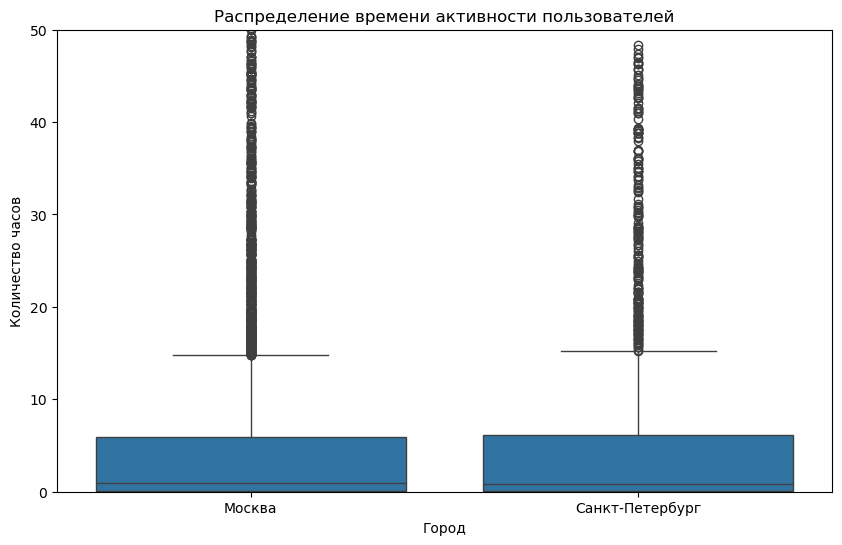

In [9]:
df_clean = pd.concat([moscow, spb])

plt.figure(figsize=(10, 6))
sns.boxplot(data = df_clean,
            x='city',
            y='hours')
            

plt.ylim(0, 50)

plt.title('Распределение времени активности пользователей')
plt.xlabel('Город')
plt.ylabel('Количество часов')

plt.show()

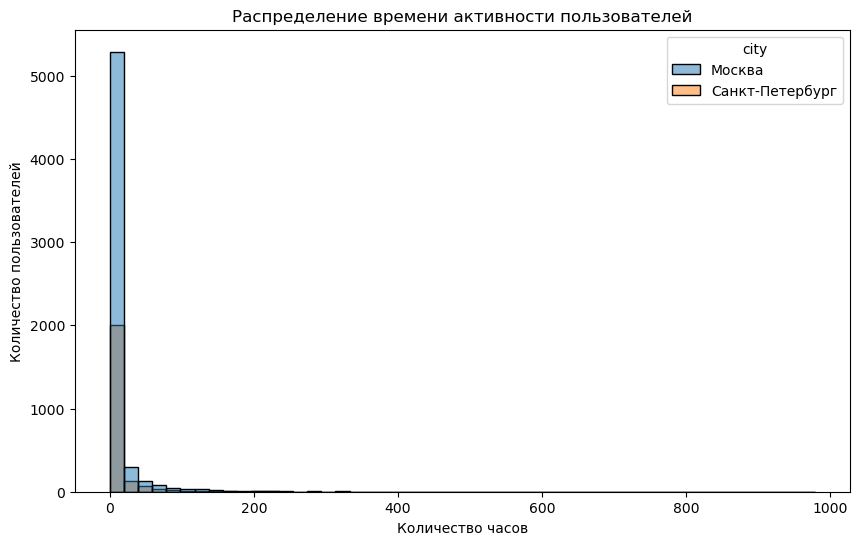

In [10]:
plt.figure(figsize= (10,6))

sns.histplot(data = df_clean,
             x = 'hours',
             hue = 'city',
             bins = 50)

plt.title('Распределение времени активности пользователей')
plt.xlabel('Количество часов')
plt.ylabel('Количество пользователей')

plt.show()

**Вывод:** распределение времени активности пользователей имеет выраженную правостороннюю асимметрию и содержит большое количество выбросов. Большинство пользователей проводит в приложении относительно немного времени, при этом отдельные пользователи имеют значительно более высокую активность. Распределение визуально отличается от нормального.

In [11]:
# IQR выбросы
groups = {'Москва': moscow,
          'Санкт-Петербург': spb}

for city, df in groups.items():
    q1 = df['hours'].quantile(0.25)
    q3 = df['hours'].quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    
    outliers = df[df['hours'] > upper]
    
    print(f'{city}:')
    print()
    print(f'Верхняя граница прослушаных часов город: {upper}')
    print(f'Количество выбросов: {len(outliers)}')
    print(f'Доля выбросов: {len(outliers)/len(df):.2%}')
    print('\nТоп-10 максимальных значений:')
    display(outliers[['puid', 'hours']].sort_values('hours', ascending=False).head(10))
    print('---'*20)
    print()

Москва:

Верхняя граница прослушаных часов город: 14.748035290404815
Количество выбросов: 866
Доля выбросов: 14.46%

Топ-10 максимальных значений:


,puid,hours
4916,1593895119,857.209373
4583,1477698281,844.267237
5416,1740160017,766.344361
4751,1537872545,504.101255
3077,863303919,462.609644
5717,1893804166,446.336651
32,2486265,440.374743
4307,1393895878,399.863422
5655,1875511616,376.859444
693,72474334,374.251589


------------------------------------------------------------

Санкт-Петербург:

Верхняя граница прослушаных часов город: 15.255799062500003
Количество выбросов: 346
Доля выбросов: 15.00%

Топ-10 максимальных значений:


,puid,hours
8646,1955354009,978.764775
6894,363654228,632.567686
6895,364116225,477.779105
8361,1697905395,449.577549
6824,312658411,433.888548
6661,173626477,319.845725
8635,1947202545,313.519445
6258,5681449,299.107557
6337,21849219,275.408056
7629,1010872013,265.128333


------------------------------------------------------------



**Вывод:** методом межквартильного размаха были выявлены статистические выбросы в обеих группах. В Москве их количество составило 866 пользователей (14,46% выборки), в Санкт-Петербурге - 346 пользователей (15,00% выборки). При этом высокие значения активности наблюдаются в сопоставимой доле пользователей обеих групп и могут отражать реальное поведение наиболее активной аудитории. Поскольку нет оснований считать эти значения ошибками данных, выбросы были сохранены для дальнейшего анализа.

# Проверка гипотезы

**Гипотеза:** пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы.

**Нулевая гипотеза H₀:** Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

**Альтернативная гипотеза H₁:** Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

Для проверки гипотезы выбран односторонний t-тест Уэлча для двух независимых выборок, так как сравниваются средние значения времени активности пользователей Москвы и Санкт-Петербурга. Тест Уэлча не предполагает равенства дисперсий между группами, а большой размер выборок позволяет использовать его несмотря на ненормальное распределение данных и наличие выбросов благодаря центральной предельной теореме.

In [12]:
# Считаем средние
moscow_mean = moscow['hours'].mean().round(2)
spb_mean = spb['hours'].mean().round(2)

print(f'Среднее время активности пользователей в Москве: {moscow_mean}')
print(f'Среднее время активности пользователей в Санкт-Петербурге: {spb_mean}')
print('---'*40)

# Применяем t-тест Уэлча
results = st.ttest_ind(spb['hours'],
                       moscow['hours'],
                       equal_var=False,
                       alternative='greater')
pvalue = results.pvalue
print(f'pvalue = {pvalue}')
print('---'*40)

alpha = 0.05

if pvalue < alpha:
    print(f'Есть основания отвергнуть нулевую гипотезу: '
          f'p-value = {pvalue} < alpha = {alpha}\n'
          'Среднее время активности пользователей в Санкт-Петербурге '
          'статистически значимо больше, чем в Москве.')
else:
    print(f'Нет оснований отвергнуть нулевую гипотезу: '
          f'p-value = {pvalue} >= alpha = {alpha}\n'
          'Статистически значимых оснований утверждать, что пользователи '
          'Санкт-Петербурга проводят больше времени в приложении, нет.')

Среднее время активности пользователей в Москве: 10.85
Среднее время активности пользователей в Санкт-Петербурге: 11.26
------------------------------------------------------------------------------------------------------------------------
pvalue = 0.33179596018475044
------------------------------------------------------------------------------------------------------------------------
Нет оснований отвергнуть нулевую гипотезу: p-value = 0.33179596018475044 >= alpha = 0.05
Статистически значимых оснований утверждать, что пользователи Санкт-Петербурга проводят больше времени в приложении, нет.


# Аналитические выводы

Для проверки гипотезы был выбран односторонний t-тест Уэлча для двух независимых выборок с уровнем статистической значимости 5%. Несмотря на ненормальное распределение данных и наличие выбросов, большой размер выборок позволяет использовать данный тест благодаря центральной предельной теореме.

Среднее время активности пользователей Москвы составило 10,85 часа, а пользователей Санкт-Петербурга - 11,26 часа. По результатам t-теста получено значение p-value = 0,33, что превышает установленный уровень статистической значимости α = 0,05.

Таким образом, статистически значимых оснований утверждать, что пользователи Санкт-Петербурга проводят больше времени за чтением и прослушиванием книг, чем пользователи Москвы, не обнаружено.

Возможной причиной отсутствия статистически значимых различий может быть схожесть аудитории Москвы и Санкт-Петербурга как крупнейших мегаполисов с похожим образом жизни и цифровыми привычками. Кроме того, на время активности пользователей могут сильнее влиять индивидуальные предпочтения и интерес к контенту, чем город проживания.